# 🚖 NYC Yellow Taxi Trip Duration Prediction
## Naive Approach - Just Exploring Data & Building Models

In [1]:
# Import what we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports done")

✅ Imports done


In [2]:
# Load the data
import kagglehub
path = kagglehub.dataset_download("elemento/nyc-yellow-taxi-trip-data")
file = f"{path}/yellow_tripdata_2016-01.csv"

# Read a sample of the data
chunks = pd.read_csv(file, chunksize=500000, low_memory=False)
df = next(chunks)
print(f"📊 Loaded {len(df):,} rows")
print(f"📋 Columns: {len(df.columns)}")

📊 Loaded 500,000 rows
📋 Columns: 19


In [3]:
# Take a quick look
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2016-01-01 00:00:00,2016-01-01 00:00:00,2,1.10,-73.990372,40.734695,1,N,-73.981842,40.732407,2,7.5,0.5,0.5,0.0,0.0,0.3,8.8
1,2,2016-01-01 00:00:00,2016-01-01 00:00:00,5,4.90,-73.980782,40.729912,1,N,-73.944473,40.716679,1,18.0,0.5,0.5,0.0,0.0,0.3,19.3
2,2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,10.54,-73.984550,40.679565,1,N,-73.950272,40.788925,1,33.0,0.5,0.5,0.0,0.0,0.3,34.3
3,2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,4.75,-73.993469,40.718990,1,N,-73.962242,40.657333,2,16.5,0.0,0.5,0.0,0.0,0.3,17.3
4,2,2016-01-01 00:00:00,2016-01-01 00:00:00,3,1.76,-73.960625,40.781330,1,N,-73.977264,40.758514,2,8.0,0.0,0.5,0.0,0.0,0.3,8.8


In [4]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               500000 non-null  int64  
 1   tpep_pickup_datetime   500000 non-null  object 
 2   tpep_dropoff_datetime  500000 non-null  object 
 3   passenger_count        500000 non-null  int64  
 4   trip_distance          500000 non-null  float64
 5   pickup_longitude       500000 non-null  float64
 6   pickup_latitude        500000 non-null  float64
 7   RatecodeID             500000 non-null  int64  
 8   store_and_fwd_flag     500000 non-null  object 
 9   dropoff_longitude      500000 non-null  float64
 10  dropoff_latitude       500000 non-null  float64
 11  payment_type           500000 non-null  int64  
 12  fare_amount            500000 non-null  float64
 13  extra                  500000 non-null  float64
 14  mta_tax                500000 non-nu

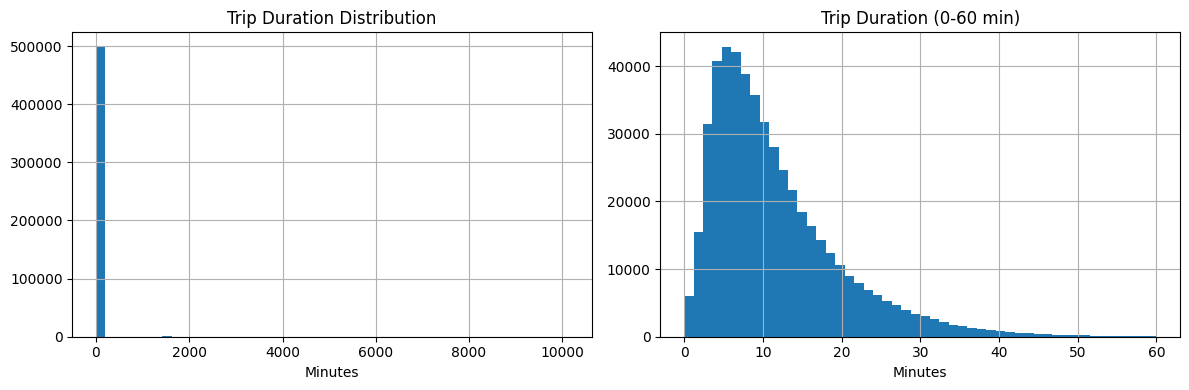

Mean: 14.9 min
Median: 9.5 min


In [5]:
# Create target variable - trip duration in minutes
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Check trip duration distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df['trip_duration'].hist(bins=50)
plt.title('Trip Duration Distribution')
plt.xlabel('Minutes')

plt.subplot(1, 2, 2)
df['trip_duration'].hist(bins=50, range=(0, 60))
plt.title('Trip Duration (0-60 min)')
plt.xlabel('Minutes')
plt.tight_layout()
plt.show()

print(f"Mean: {df['trip_duration'].mean():.1f} min")
print(f"Median: {df['trip_duration'].median():.1f} min")

In [6]:
# Filter out unrealistic trips
df = df[df['trip_duration'] > 1]  # At least 1 minute
df = df[df['trip_duration'] < 120]  # Less than 2 hours
df = df[df['trip_distance'] > 0]  # Positive distance
df = df[df['trip_distance'] < 50]  # Less than 50 miles
df = df[df['passenger_count'] > 0]  # At least 1 passenger
df = df[df['passenger_count'] <= 6]  # Max 6 passengers
df = df.dropna()  # Drop missing values

print(f"After filtering: {len(df):,} rows")

After filtering: 493,231 rows


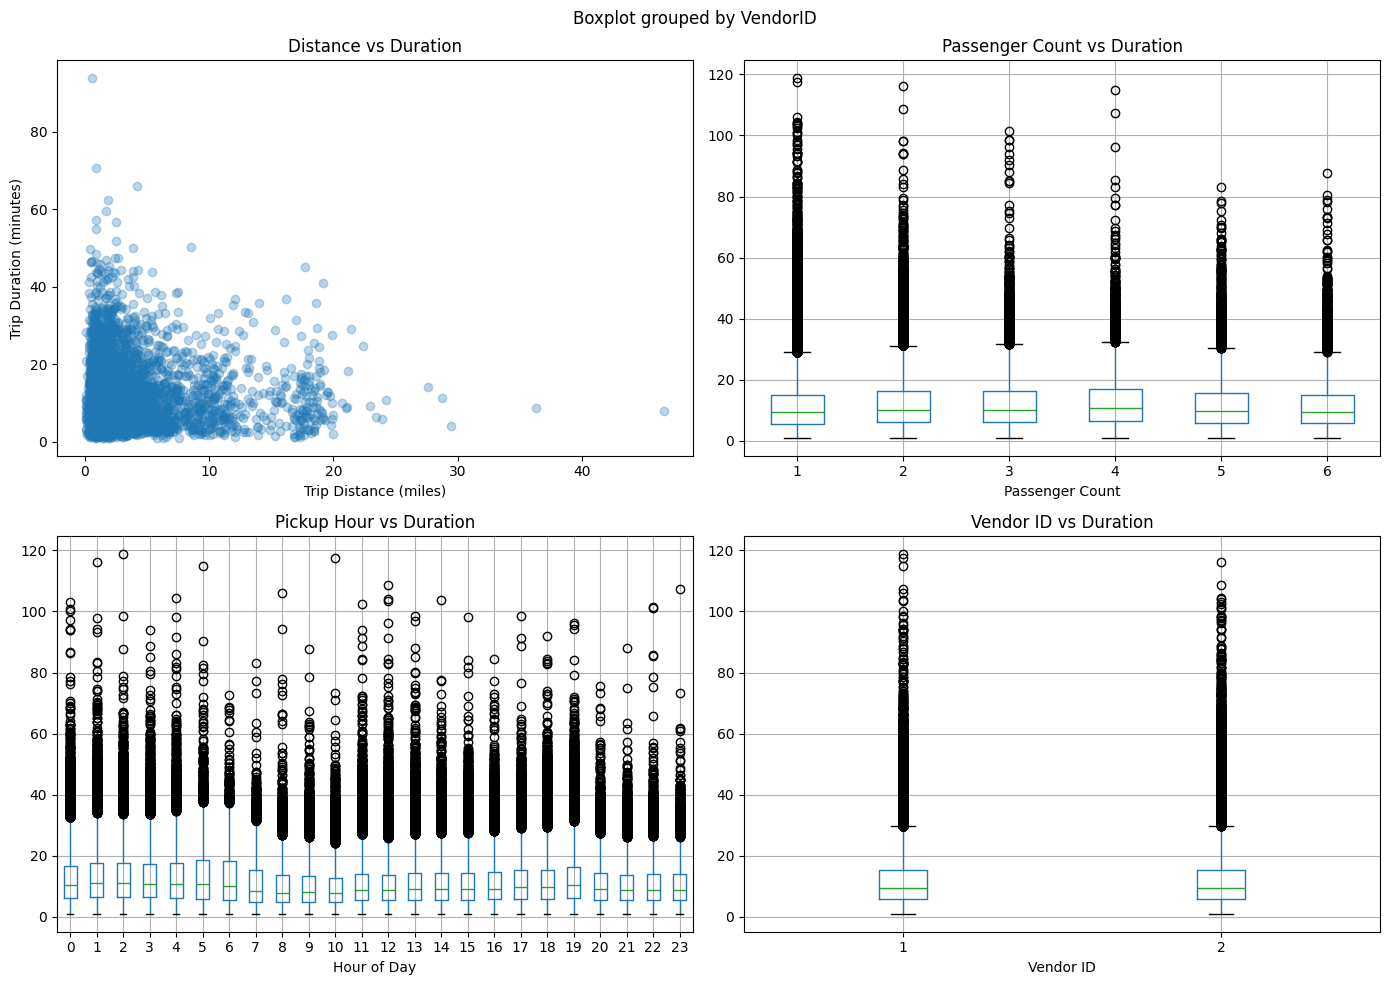

In [7]:
# Explore relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Trip distance vs duration
axes[0, 0].scatter(df['trip_distance'].sample(5000), df['trip_duration'].sample(5000), alpha=0.3)
axes[0, 0].set_xlabel('Trip Distance (miles)')
axes[0, 0].set_ylabel('Trip Duration (minutes)')
axes[0, 0].set_title('Distance vs Duration')

# Passenger count vs duration
df.boxplot(column='trip_duration', by='passenger_count', ax=axes[0, 1])
axes[0, 1].set_title('Passenger Count vs Duration')
axes[0, 1].set_xlabel('Passenger Count')

# Pickup hour vs duration
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df.boxplot(column='trip_duration', by='pickup_hour', ax=axes[1, 0])
axes[1, 0].set_title('Pickup Hour vs Duration')
axes[1, 0].set_xlabel('Hour of Day')

# Vendor comparison
df.boxplot(column='trip_duration', by='VendorID', ax=axes[1, 1])
axes[1, 1].set_title('Vendor ID vs Duration')
axes[1, 1].set_xlabel('Vendor ID')

plt.tight_layout()
plt.show()

In [8]:
# Feature engineering - create useful features

# 1. Haversine distance (great circle distance)
def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['haversine_dist'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# 2. Time-based features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

# 3. Rush hour flag
df['is_rush_hour'] = ((df['pickup_hour'] >= 7) & (df['pickup_hour'] <= 9)) | \
                     ((df['pickup_hour'] >= 16) & (df['pickup_hour'] <= 18))

# 4. Efficiency metric
df['directness'] = df['haversine_dist'] / df['trip_distance']

print("✅ Feature engineering complete")
print(f"Total features: {df.shape[1]}")

✅ Feature engineering complete
Total features: 27


In [9]:
# Select features for modeling
feature_cols = [
    'trip_distance',
    'haversine_dist',
    'passenger_count',
    'pickup_hour',
    'pickup_dayofweek',
    'is_rush_hour',
    'directness',
    'VendorID',
    'RatecodeID',
    'payment_type'
]

X = df[feature_cols]
y = df['trip_duration']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (493231, 10)
y shape: (493231,)


In [10]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test: {X_test.shape[0]:,} rows")

Train: 394,584 rows
Test: 98,647 rows


In [11]:
# 🤖 Try different models
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline

models = {
    'Linear Regression': LinearRegression(),
    'Polynomial Regression': make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
}

results = {}

for name, model in models.items():
    print(f"\n🔍 Training {name}...")
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Evaluate
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    results[name] = {
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'model': model
    }
    
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²:  {test_r2:.4f}")
    print(f"  Test MAE: {test_mae:.2f} minutes")
    print(f"  Test RMSE: {test_rmse:.2f} minutes")


🔍 Training Linear Regression...
  Train R²: 0.6493
  Test R²:  0.6443
  Test MAE: 3.48 minutes
  Test RMSE: 4.97 minutes

🔍 Training Polynomial Regression...
  Train R²: 0.7131
  Test R²:  0.7067
  Test MAE: 3.01 minutes
  Test RMSE: 4.51 minutes


In [12]:
# Compare models
results_df = pd.DataFrame({
    name: {
        'Test R²': f"{metrics['test_r2']:.4f}",
        'Test MAE': f"{metrics['test_mae']:.2f} min",
        'Test RMSE': f"{metrics['test_rmse']:.2f} min"
    }
    for name, metrics in results.items()
}).T

results_df

,Test R²,Test MAE,Test RMSE
Linear Regression,0.6443,3.48 min,4.97 min
Polynomial Regression,0.7067,3.01 min,4.51 min


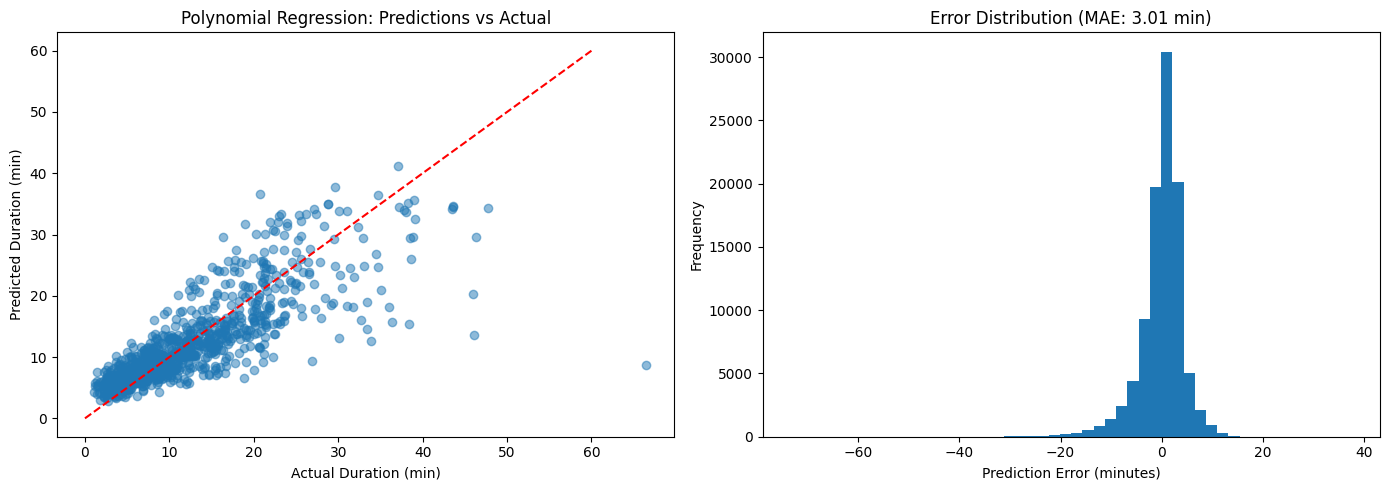

In [13]:
# Visualize predictions vs actual for best model
best_model_name = max(results, key=lambda x: results[x]['test_r2'])
best_model = results[best_model_name]['model']

y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test[:1000], y_pred[:1000], alpha=0.5)
plt.plot([0, 60], [0, 60], 'r--')
plt.xlabel('Actual Duration (min)')
plt.ylabel('Predicted Duration (min)')
plt.title(f'{best_model_name}: Predictions vs Actual')

plt.subplot(1, 2, 2)
errors = y_pred - y_test
plt.hist(errors, bins=50)
plt.xlabel('Prediction Error (minutes)')
plt.ylabel('Frequency')
plt.title(f'Error Distribution (MAE: {results[best_model_name]["test_mae"]:.2f} min)')

plt.tight_layout()
plt.show()

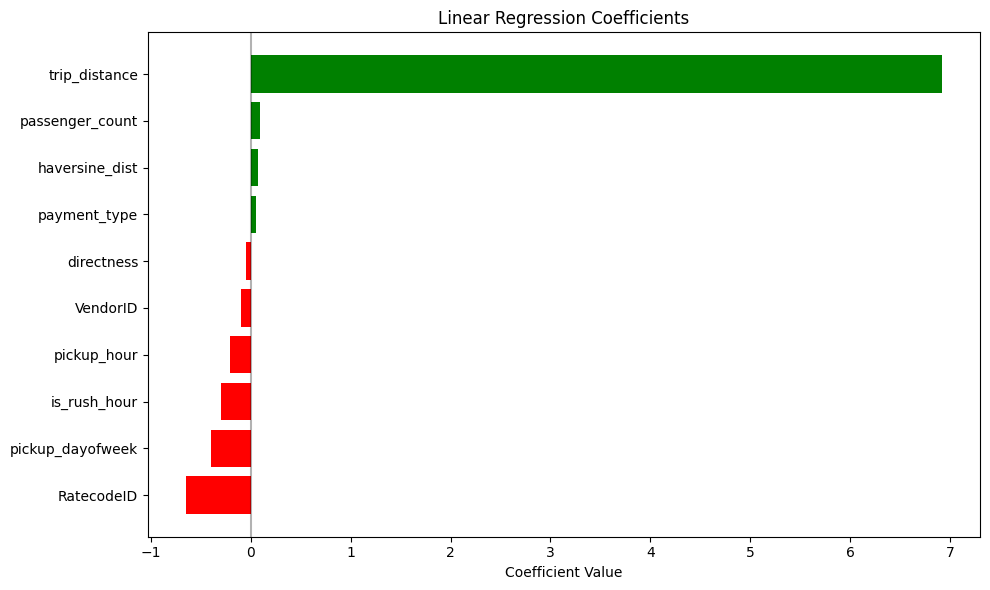


Top 5 positive coefficients:
        feature  coefficient
  trip_distance     6.923950
passenger_count     0.089412
 haversine_dist     0.066081
   payment_type     0.047351
     directness    -0.050520

Top 5 negative coefficients:
         feature  coefficient
        VendorID    -0.101543
     pickup_hour    -0.210160
    is_rush_hour    -0.299041
pickup_dayofweek    -0.396501
      RatecodeID    -0.652789

📌 Note: Polynomial and SVM models don't provide direct feature importance


In [14]:
# Feature importance for Linear Regression coefficients
if 'Linear Regression' in results:
    lr_model = results['Linear Regression']['model']
    coefficients = lr_model.coef_
    
    coef_df = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': coefficients
    }).sort_values('coefficient', ascending=False)
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if x > 0 else 'red' for x in coef_df['coefficient']]
    plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
    plt.xlabel('Coefficient Value')
    plt.title('Linear Regression Coefficients')
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 positive coefficients:")
    print(coef_df.head().to_string(index=False))
    print("\nTop 5 negative coefficients:")
    print(coef_df.tail().to_string(index=False))

# Note: SVM and Polynomial Regression don't have direct feature importance
# Polynomial has too many features, SVM coefficients aren't directly interpretable
print("\n📌 Note: Polynomial and SVM models don't provide direct feature importance")

In [15]:
# Save the best model
import joblib
joblib.dump(best_model, 'nyc_taxi_first_experiment.pkl')
joblib.dump(scaler, 'nyc_taxi_scaler.pkl')

print(f"✅ Best model ({best_model_name}) saved!")

✅ Best model (Polynomial Regression) saved!


In [16]:
# Simple prediction function
def predict_duration(distance, hour, passengers=1, vendor=2, rate=1, payment=1):
    """
    Simple prediction function for trip duration
    """
    # Create feature array with reasonable defaults
    features = np.array([[
        distance,          # trip_distance
        distance * 1.1,    # haversine_dist (approximate)
        passengers,        # passenger_count
        hour,             # pickup_hour
        2,                # pickup_dayofweek (Tuesday)
        1 if (7 <= hour <= 9) or (16 <= hour <= 18) else 0,  # is_rush_hour
        0.9,             # directness
        vendor,          # VendorID
        rate,           # RatecodeID
        payment         # payment_type
    ]])
    
    features_scaled = scaler.transform(features)
    prediction = best_model.predict(features_scaled)[0]
    
    return max(1, round(prediction, 1))

# Test the function
example = predict_duration(distance=2.5, hour=17)
print(f"🚖 Predicted duration for 2.5 mile trip at 5pm: {example} minutes")

🚖 Predicted duration for 2.5 mile trip at 5pm: 1 minutes


In [17]:
# Quick summary
print("=" * 50)
print("📊 NYC TAXI TRIP DURATION - NAIVE MODEL")
print("=" * 50)
print(f"Best model: {best_model_name}")
print(f"Test R²: {results[best_model_name]['test_r2']:.4f}")
print(f"Test MAE: {results[best_model_name]['test_mae']:.2f} minutes")
print(f"Test RMSE: {results[best_model_name]['test_rmse']:.2f} minutes")
print(f"\nFeatures used: {len(feature_cols)}")
print(f"Training samples: {X_train.shape[0]:,}")
print(f"Model saved: nyc_taxi_model.pkl")

📊 NYC TAXI TRIP DURATION - NAIVE MODEL
Best model: Polynomial Regression
Test R²: 0.7067
Test MAE: 3.01 minutes
Test RMSE: 4.51 minutes

Features used: 10
Training samples: 394,584
Model saved: nyc_taxi_model.pkl
